<a href="https://colab.research.google.com/github/chitrasavithri176-cmyk/OIBSIP/blob/main/OIBSIP_DATASCIENCE_TASK_3_Car_Price_Prediction_with_Machine_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Car Price Prediction Pipeline**
This notebook demonstrates a structured machine learning pipeline using the **Car Dekho Dataset** to predict used car selling prices.

### **Pipeline Overview**
1. **Data Loading & Overview**: Load and inspect the dataset shape, datatypes, and columns.
2. **Data Cleaning & Standardization**: Handle duplicates, null values, and strip/normalize categorical columns.
3. **Feature Engineering**: Create meaningful features like `car_age` and the manufacturer's `brand`.
4. **Exploratory Data Analysis (EDA)**: Understand underlying relationships and distributions using charts.
5. **Feature Encoding**: Prepare categorical variables for modeling via Ordinal and One-Hot Encoding.
6. **Model Training & Evaluation**: Train and compare baseline Linear Regression against a Random Forest Regressor.
7. **Feature Importance**: Analyze which features influence selling prices the most.

### **Step 1: Data Loading & Initial Inspection**

In [ ]:
import pandas as pd


file_path = '/content/CAR DETAILS FROM CAR DEKHO.csv'
df = pd.read_csv(file_path)

print("--- Original Dataset Overview ---")
display(df.info())
display(df.head())

--- Original Dataset Overview ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4340 entries, 0 to 4339
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   name           4340 non-null   object
 1   year           4340 non-null   int64 
 2   selling_price  4340 non-null   int64 
 3   km_driven      4340 non-null   int64 
 4   fuel           4340 non-null   object
 5   seller_type    4340 non-null   object
 6   transmission   4340 non-null   object
 7   owner          4340 non-null   object
dtypes: int64(3), object(5)
memory usage: 271.4+ KB


None

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


### **Step 2: Data Cleaning & Standardization**

In [ ]:

print("Missing values per column:")
print(df.isnull().sum())


df = df.dropna()


duplicate_count = df.duplicated().sum()
print(f"\nNumber of duplicate rows found: {duplicate_count}")
if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates successfully removed.")

categorical_cols = ['fuel', 'seller_type', 'transmission', 'owner']
for col in categorical_cols:

    df[col] = df[col].astype(str).str.strip().str.capitalize()

print("\n--- Cleaned Dataset Unique Values ---")
for col in categorical_cols:
    print(f"Unique values in '{col}': {df[col].unique()}")

Missing values per column:
name             0
year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
dtype: int64

Number of duplicate rows found: 763
Duplicates successfully removed.

--- Cleaned Dataset Unique Values ---
Unique values in 'fuel': ['Petrol' 'Diesel' 'Cng' 'Lpg' 'Electric']
Unique values in 'seller_type': ['Individual' 'Dealer' 'Trustmark dealer']
Unique values in 'transmission': ['Manual' 'Automatic']
Unique values in 'owner': ['First owner' 'Second owner' 'Fourth & above owner' 'Third owner'
 'Test drive car']


### **Step 3: Feature Engineering**

In [ ]:
import datetime


current_year = datetime.datetime.now().year
df['car_age'] = current_year - df['year']


df['brand'] = df['name'].apply(lambda x: x.split()[0].capitalize())


display(df[['name', 'year', 'car_age', 'brand']].head())
print(f"Total unique brands extracted: {df['brand'].nunique()}")

,name,year,car_age,brand
0,Maruti 800 AC,2007,19,Maruti
1,Maruti Wagon R LXI Minor,2007,19,Maruti
2,Hyundai Verna 1.6 SX,2012,14,Hyundai
3,Datsun RediGO T Option,2017,9,Datsun
4,Honda Amaze VX i-DTEC,2014,12,Honda


Total unique brands extracted: 29


### **Step 4: Exploratory Data Analysis (EDA)**

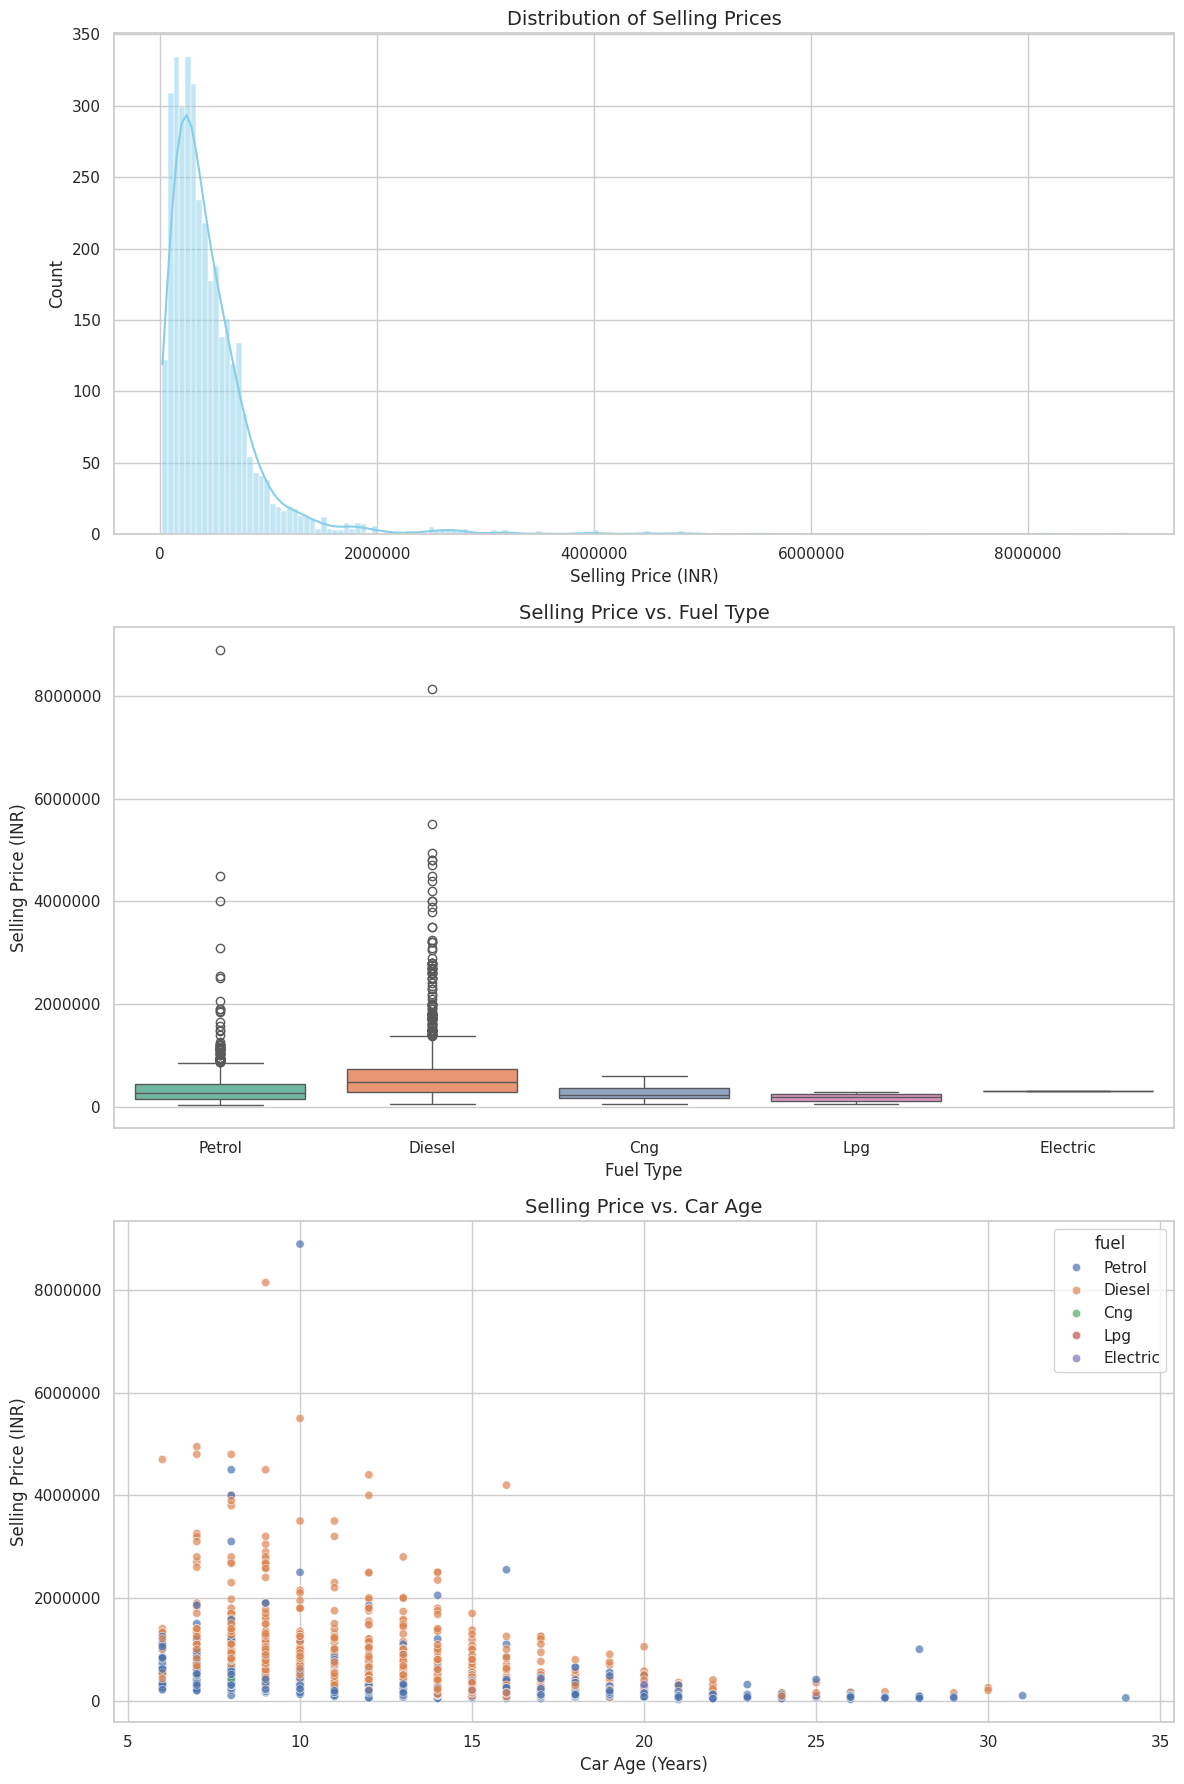

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(3, 1, figsize=(12, 18))


sns.histplot(data=df, x='selling_price', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Selling Prices', fontsize=14)
axes[0].set_xlabel('Selling Price (INR)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].ticklabel_format(style='plain', axis='x')


sns.boxplot(data=df, x='fuel', y='selling_price', hue='fuel', legend=False, ax=axes[1], palette='Set2')
axes[1].set_title('Selling Price vs. Fuel Type', fontsize=14)
axes[1].set_xlabel('Fuel Type', fontsize=12)
axes[1].set_ylabel('Selling Price (INR)', fontsize=12)
axes[1].ticklabel_format(style='plain', axis='y')


sns.scatterplot(data=df, x='car_age', y='selling_price', hue='fuel', alpha=0.7, ax=axes[2], palette='deep')
axes[2].set_title('Selling Price vs. Car Age', fontsize=14)
axes[2].set_xlabel('Car Age (Years)', fontsize=12)
axes[2].set_ylabel('Selling Price (INR)', fontsize=12)
axes[2].ticklabel_format(style='plain', axis='y')

plt.tight_layout()
plt.show()

### **Step 5: Categorical Encoding & Dataset Preparation**

In [ ]:
df_encoded = df.copy()


owner_mapping = {
    'Test drive car': 0,
    'First owner': 1,
    'Second owner': 2,
    'Third owner': 3,
    'Fourth & above owner': 4
}
df_encoded['owner_encoded'] = df_encoded['owner'].map(owner_mapping)


nominal_cols = ['fuel', 'seller_type', 'transmission', 'brand']
df_encoded = pd.get_dummies(df_encoded, columns=nominal_cols, drop_first=True, dtype=int)


df_encoded = df_encoded.drop(columns=['name', 'year', 'owner'])

print("--- Encoded Dataset Preview ---")
display(df_encoded.head())
print(f"Shape of final encoded dataset: {df_encoded.shape}")

--- Encoded Dataset Preview ---


,selling_price,km_driven,car_age,owner_encoded,fuel_Diesel,fuel_Electric,fuel_Lpg,fuel_Petrol,seller_type_Individual,seller_type_Trustmark dealer,...,brand_Mg,brand_Mitsubishi,brand_Nissan,brand_Opelcorsa,brand_Renault,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo
0,60000,70000,19,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1,135000,50000,19,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,600000,100000,14,1,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
3,250000,46000,9,1,0,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,450000,141000,12,2,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0


Shape of final encoded dataset: (3577, 39)


### **Step 6: Model Training, Comparisons, & Evaluation**

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np


X = df_encoded.drop(columns=['selling_price'])
y = df_encoded['selling_price']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


lr_model = LinearRegression()
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


lr_model.fit(X_train, y_train)
rf_model.fit(X_train, y_train)


y_pred_lr = lr_model.predict(X_test)
y_pred_rf = rf_model.predict(X_test)


def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(f"=== {model_name} Evaluation ===")
    print(f"MAE:  {mae:,.2f} INR")
    print(f"RMSE: {rmse:,.2f} INR")
    print(f"R²:   {r2:.4f}\n")
    return mae, rmse, r2

lr_metrics = evaluate_model(y_test, y_pred_lr, "Linear Regression")
rf_metrics = evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

=== Linear Regression Evaluation ===
MAE:  180,314.27 INR
RMSE: 386,085.34 INR
R²:   0.5373

=== Random Forest Regressor Evaluation ===
MAE:  159,765.87 INR
RMSE: 366,905.04 INR
R²:   0.5821



### **Step 7: Visualize Model Predictions**

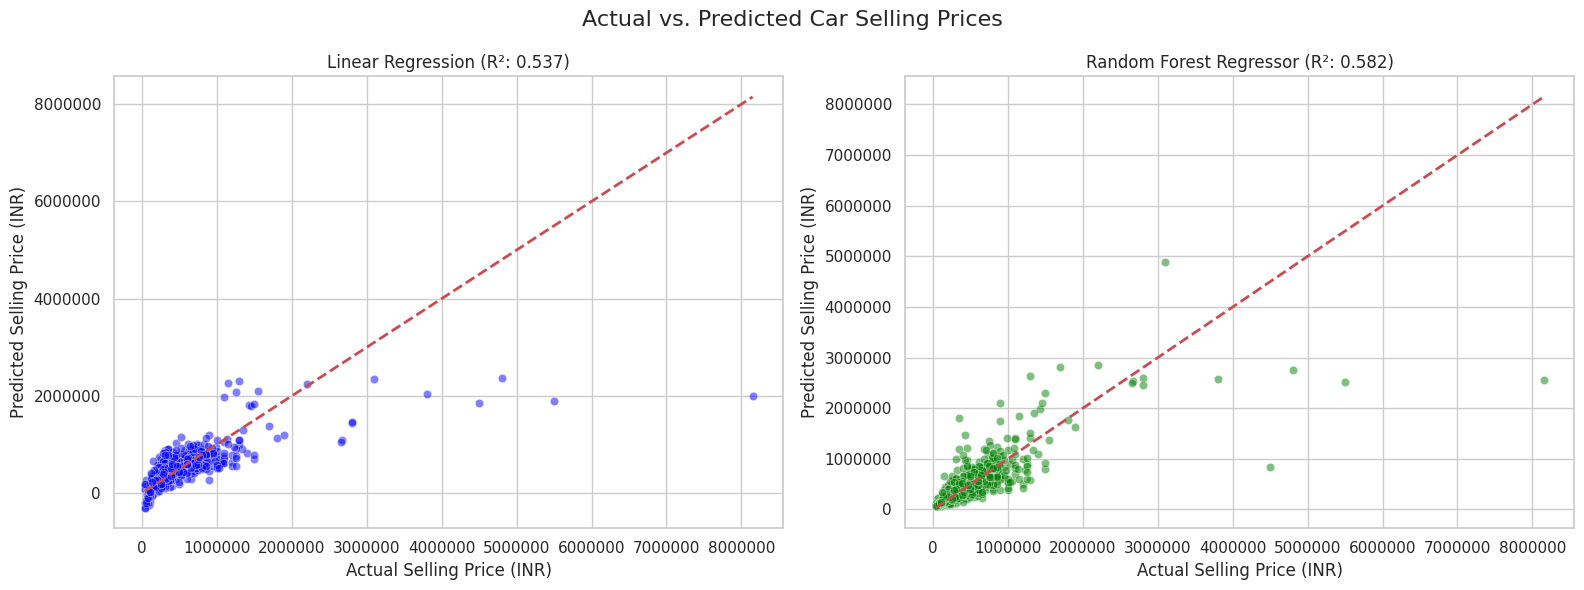

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))


sns.scatterplot(x=y_test, y=y_pred_lr, alpha=0.5, ax=axes[0], color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0].set_title(f'Linear Regression (R²: {lr_metrics[2]:.3f})')
axes[0].set_xlabel('Actual Selling Price (INR)')
axes[0].set_ylabel('Predicted Selling Price (INR)')
axes[0].ticklabel_format(style='plain')


sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.5, ax=axes[1], color='green')
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[1].set_title(f'Random Forest Regressor (R²: {rf_metrics[2]:.3f})')
axes[1].set_xlabel('Actual Selling Price (INR)')
axes[1].set_ylabel('Predicted Selling Price (INR)')
axes[1].ticklabel_format(style='plain')

plt.suptitle('Actual vs. Predicted Car Selling Prices', fontsize=16)
plt.tight_layout()
plt.show()

### **Step 8: Feature Importance Analysis**

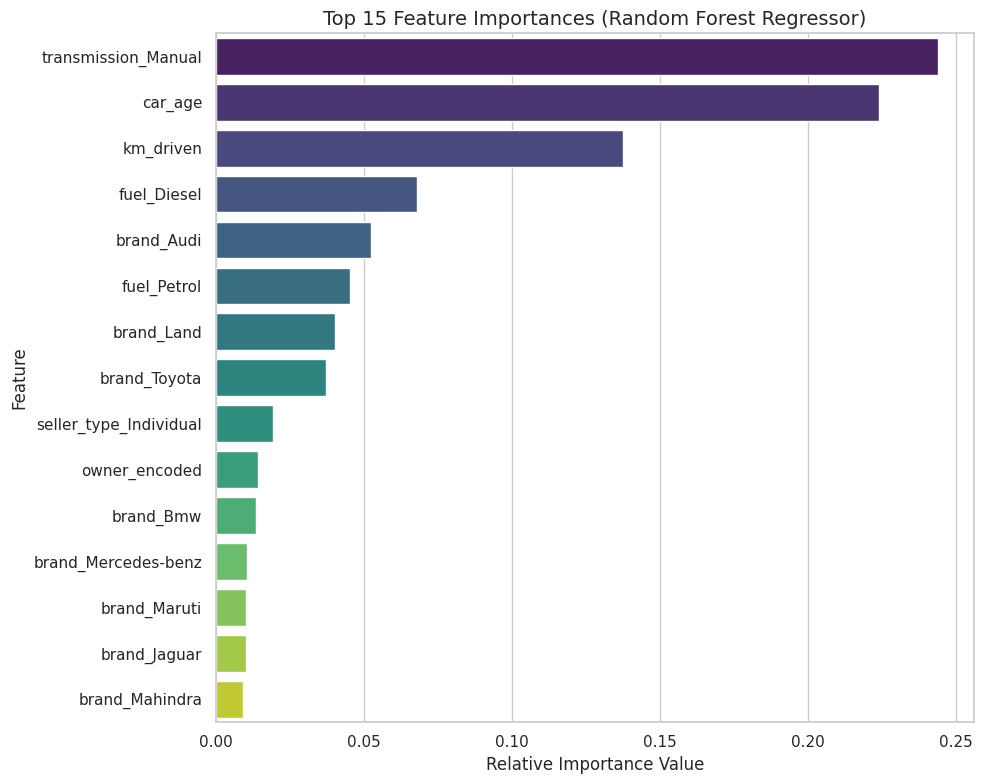

In [ ]:

importances = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)


top_n = 15
top_features = feature_importance_df.head(top_n)

plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=top_features, palette='viridis', hue='Feature', legend=False)
plt.title(f'Top {top_n} Feature Importances (Random Forest Regressor)', fontsize=14)
plt.xlabel('Relative Importance Value', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.show()



# Car Price Prediction: A Comparative Analysis of Regression Models

## Overview
This notebook demonstrates a structured, end-to-end machine learning pipeline using the **Car Dekho Dataset** to predict used car selling prices. The objective is to build predictive models that accurately forecast used car prices based on features such as car age, mileage, fuel type, transmission type, and brand, and to identify the key factors that drive the resale value of cars.

## Analysis Steps

### 1. Data Loading & Initial Inspection
* Loaded the `CAR DETAILS FROM CAR DEKHO.csv` dataset into a pandas DataFrame.
* Inspected the dataset structure, missing values, and data types. The dataset consists of 4,340 rows and 8 initial features (`name`, `year`, `selling_price`, `km_driven`, `fuel`, `seller_type`, `transmission`, `owner`).

### 2. Data Cleaning & Standardization
* Checked for missing values across all columns.
* Identified and removed 763 duplicate records, resulting in a cleaned dataset of 3,577 unique entries.
* Standardized categorical variables (`fuel`, `seller_type`, `transmission`, `owner`) by trimming whitespaces and normalizing character casing to prevent inconsistencies.

### 3. Feature Engineering
* **`car_age`**: Calculated dynamically based on the current year to capture the depreciation impact over time.
* **`brand`**: Extracted the manufacturer's brand name from the first word of the `name` column, yielding 29 unique car brands.

### 4. Exploratory Data Analysis (EDA)
* **Target Distribution**: Analyzed the distribution of `selling_price`, revealing a right-skewed distribution.
* **Categorical Visualizations**: Used box plots to compare `selling_price` across different `fuel` types.
* **Scatter Plots**: Plotted `selling_price` against `car_age` to observe negative correlation trends.
* **Correlation Analysis**: Built correlation heatmaps for both the target variable and key numerical features, highlighting correlations between transmission, age, and price.

### 5. Categorical Encoding & Dataset Preparation
* **Ordinal Encoding**: Mapped the `owner` variable to numerical values hierarchy (`Test drive car`: 0 to `Fourth & above owner`: 4).
* **One-Hot Encoding**: Applied dummy variable encoding to nominal features (`fuel`, `seller_type`, `transmission`, `brand`) while dropping the first category to avoid multi-collinearity.
* Dropped redundant columns (`name`, `year`, `owner`) to output a finalized modeling dataset of 3,577 rows and 39 columns.

### 6. Data Preprocessing & Splitting
* Separated features ($X$) from the target variable ($y$: `selling_price`).
* Split the dataset into training (80%) and testing (20%) sets using a fixed random state to ensure reproducibility.

### 7. Model Training & Comparisons
Two distinct regression algorithms were trained and evaluated on the test set:
1. **Linear Regression**: Served as the baseline model.
2. **Random Forest Regressor**: Ensembled decision trees to capture non-linear interactions.

### 8. Model Evaluation
Both models were compared using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the R-squared ($R^2$) Score:

* **Linear Regression Baseline**:
  * MAE: 180,314.27 INR
  * RMSE: 386,085.34 INR
  * $R^2$ Score: 0.5373

* **Random Forest Regressor**:
  * MAE: 159,765.87 INR
  * RMSE: 366,905.04 INR
  * $R^2$ Score: 0.5821

**Key Takeaway**: The Random Forest Regressor outperformed the Linear Regression baseline across all metrics, explaining approximately **58.21%** of the variance in used car selling prices.

### 9. Feature Importance Analysis
An analysis of the Random Forest model's feature importances revealed the top drivers of used car selling prices:
1. **`transmission_Manual`**: The most influential feature, reflecting a substantial pricing premium for automatic transmissions.
2. **`car_age`**: The second strongest predictor, showing that younger cars retain significantly higher market values.
3. **`km_driven`**: Total distance driven acts as another primary depreciating metric.
4. **`fuel_Diesel` & brand factors (e.g., `brand_Audi`)**: Engine type and luxury brand status also heavily influence overall resale valuations.

